In [1]:
import catboost

In [2]:
catboost.__version__

'1.2.10'

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from catboost import CatboostError, Pool, CatBoostRegressor

[Dataset insurance prediction](https://www.kaggle.com/datasets/thedevastator/prediction-of-insurance-charges-using-age-gender)

In [5]:
insurance_data = pd.read_csv('../datasets/insurance.csv')

In [12]:
categorical_features = insurance_data.select_dtypes(exclude=np.number).columns.tolist()
print(categorical_features)

insurance_data[categorical_features] = insurance_data[categorical_features].astype('str').fillna('nan')

['sex', 'smoker', 'region']


In [13]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1336 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1336 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [15]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
X = insurance_data.drop('charges', axis=1)
y = insurance_data['charges']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((1070, 6), (268, 6))

In [18]:
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)


In [20]:
model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    verbose=20,

)

model.fit(train_pool)

0:	learn: 11131.4972651	total: 56.8ms	remaining: 11.3s
20:	learn: 4865.9620877	total: 148ms	remaining: 1.26s
40:	learn: 4390.8127179	total: 301ms	remaining: 1.17s
60:	learn: 4289.8396830	total: 408ms	remaining: 929ms
80:	learn: 4217.5644725	total: 482ms	remaining: 708ms
100:	learn: 4151.2047582	total: 585ms	remaining: 573ms
120:	learn: 4037.5768034	total: 694ms	remaining: 453ms
140:	learn: 3945.2295008	total: 823ms	remaining: 344ms
160:	learn: 3892.8692667	total: 924ms	remaining: 224ms
180:	learn: 3828.8975749	total: 1.01s	remaining: 106ms
199:	learn: 3760.1923162	total: 1.17s	remaining: 0us


CatBoostRegressor(depth=6, iterations=200, learning_rate=0.1, loss_function='RMSE', verbose=20)

In [27]:
def compute_metrics(model):
    y_pred = model.predict(test_pool)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}")

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(y_test, y_pred, alpha=0.5)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val],
            [min_val, max_val],
            color='red',
            linestyle='--',
            linewidth=2)


    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title('Actual Price vs.Predicted Price')

    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

In [29]:
y.min(), y.max()

(np.float64(1121.8739), np.float64(63770.42801))

MAE: 2294.6629317190527
MSE: 18723284.472430564
RMSE: 4327.041075888992
R2 Score: 0.879398148425949


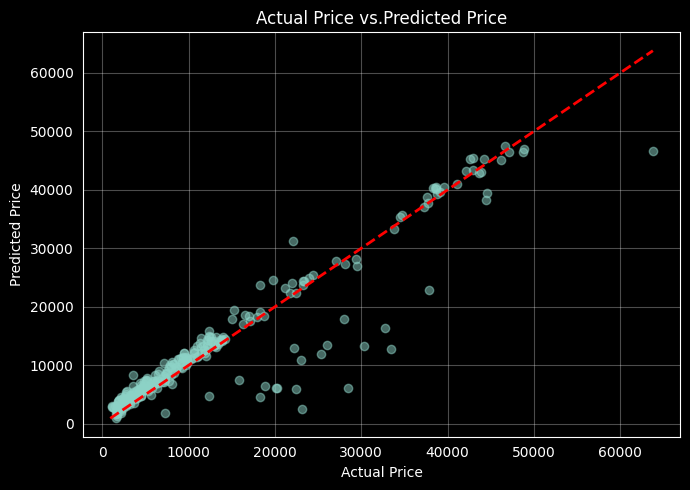

In [28]:
compute_metrics(model)

In [30]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  %%jav

In [31]:
X_train_es, X_val, y_train_es, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train_es.shape, X_val.shape

train_pool = Pool(X_train_es, y_train_es, cat_features=categorical_features)

val_pool = Pool(X_val, y_val, cat_features=categorical_features)

test_pool = Pool(X_test, y_test, cat_features=categorical_features)

In [32]:
%%timeit

model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    subsample=0.8,
    bootstrap_type='Bernoulli',
    verbose=50,

)

model.fit(train_pool, eval_set=val_pool)

0:	learn: 10982.6910296	test: 11767.3881206	best: 11767.3881206 (0)	total: 14.8ms	remaining: 4.43s
50:	learn: 4088.8843815	test: 5308.2528688	best: 5308.2528688 (50)	total: 307ms	remaining: 1.5s
100:	learn: 3694.7918820	test: 5340.2661222	best: 5288.1968698 (63)	total: 515ms	remaining: 1.01s
150:	learn: 3390.5088790	test: 5389.2166657	best: 5288.1968698 (63)	total: 797ms	remaining: 786ms
200:	learn: 3108.3242020	test: 5451.8852899	best: 5288.1968698 (63)	total: 1.15s	remaining: 569ms
250:	learn: 2905.7385225	test: 5479.4255573	best: 5288.1968698 (63)	total: 1.48s	remaining: 290ms
299:	learn: 2700.6400802	test: 5532.6716761	best: 5288.1968698 (63)	total: 1.72s	remaining: 0us

bestTest = 5288.19687
bestIteration = 63

Shrink model to first 64 iterations.
0:	learn: 10982.6910296	test: 11767.3881206	best: 11767.3881206 (0)	total: 13.7ms	remaining: 4.08s
50:	learn: 4088.8843815	test: 5308.2528688	best: 5308.2528688 (50)	total: 309ms	remaining: 1.51s
100:	learn: 3694.7918820	test: 5340.26612

MAE: 2294.6629317190527
MSE: 18723284.472430564
RMSE: 4327.041075888992
R2 Score: 0.879398148425949


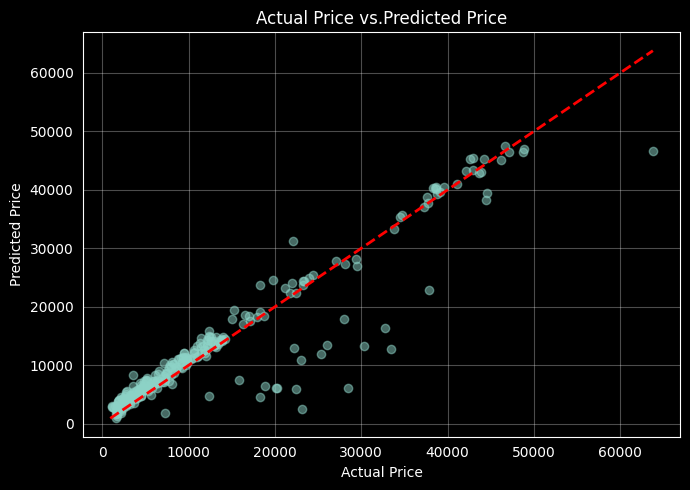

In [33]:
compute_metrics(model)

In [34]:
%%timeit

model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    subsample=0.8,
    bootstrap_type='Bernoulli',
    od_type='Iter',
    od_wait=40,
    verbose=50,

)

model.fit(train_pool, eval_set=val_pool)

0:	learn: 10982.6910296	test: 11767.3881206	best: 11767.3881206 (0)	total: 12.7ms	remaining: 3.8s
50:	learn: 4088.8843815	test: 5308.2528688	best: 5308.2528688 (50)	total: 331ms	remaining: 1.61s
100:	learn: 3694.7918820	test: 5340.2661222	best: 5288.1968698 (63)	total: 591ms	remaining: 1.17s
Stopped by overfitting detector  (40 iterations wait)

bestTest = 5288.19687
bestIteration = 63

Shrink model to first 64 iterations.
0:	learn: 10982.6910296	test: 11767.3881206	best: 11767.3881206 (0)	total: 2.83ms	remaining: 847ms
50:	learn: 4088.8843815	test: 5308.2528688	best: 5308.2528688 (50)	total: 192ms	remaining: 939ms
100:	learn: 3694.7918820	test: 5340.2661222	best: 5288.1968698 (63)	total: 551ms	remaining: 1.08s
Stopped by overfitting detector  (40 iterations wait)

bestTest = 5288.19687
bestIteration = 63

Shrink model to first 64 iterations.
0:	learn: 10982.6910296	test: 11767.3881206	best: 11767.3881206 (0)	total: 2.36ms	remaining: 706ms
50:	learn: 4088.8843815	test: 5308.2528688	bes

MAE: 2294.6629317190527
MSE: 18723284.472430564
RMSE: 4327.041075888992
R2 Score: 0.879398148425949


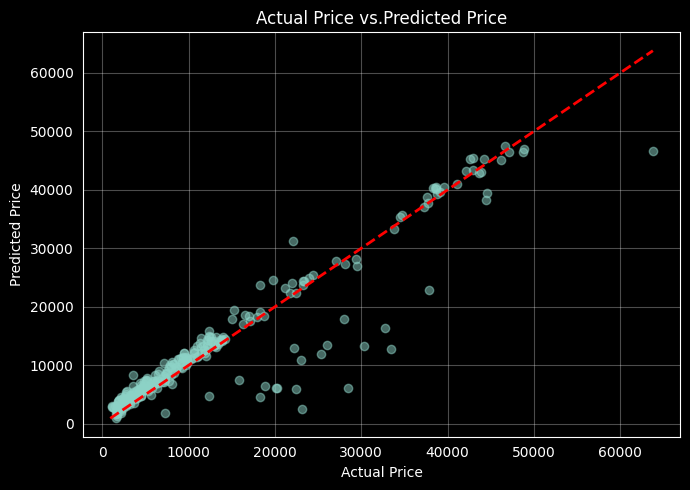

In [35]:
compute_metrics(model)

    Feature  Importance
4    smoker   74.269323
2       bmi   14.080614
0       age    9.360705
3  children    1.299580
5    region    0.760590
1       sex    0.229188


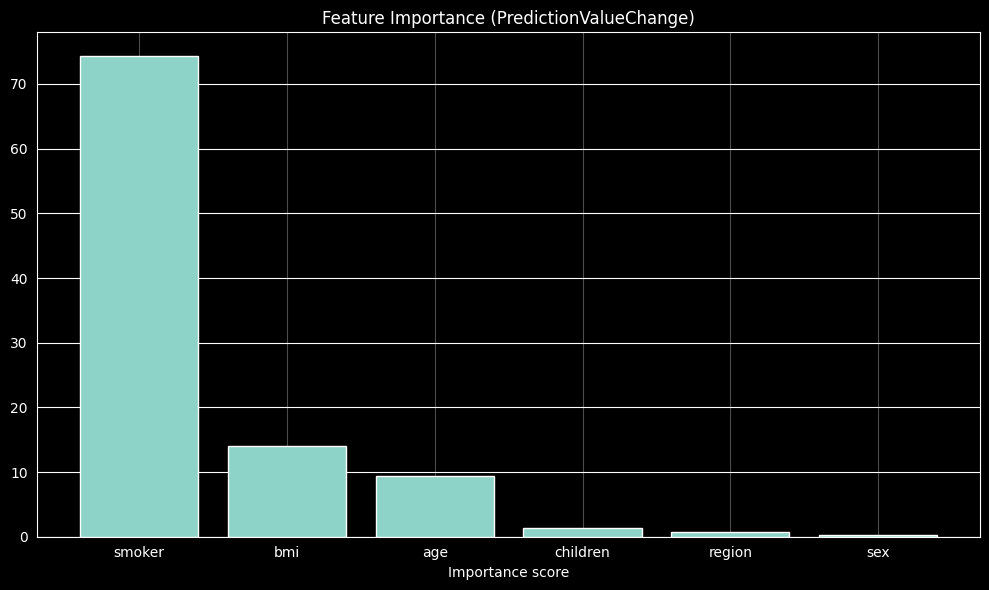

In [40]:
importance_pvc = model.get_feature_importance(train_pool, type="PredictionValuesChange")

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Importance": importance_pvc
        }
    )
    .sort_values("Importance", ascending=False)
)


print(feature_importance_df)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

ax.set_title("Feature Importance (PredictionValueChange)")
ax.set_xlabel("Importance score")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

    Feature   Importance
4    smoker  6583.959489
0       age  1490.172873
2       bmi  1180.296049
3  children   101.729786
5    region    49.581402
1       sex    17.132683


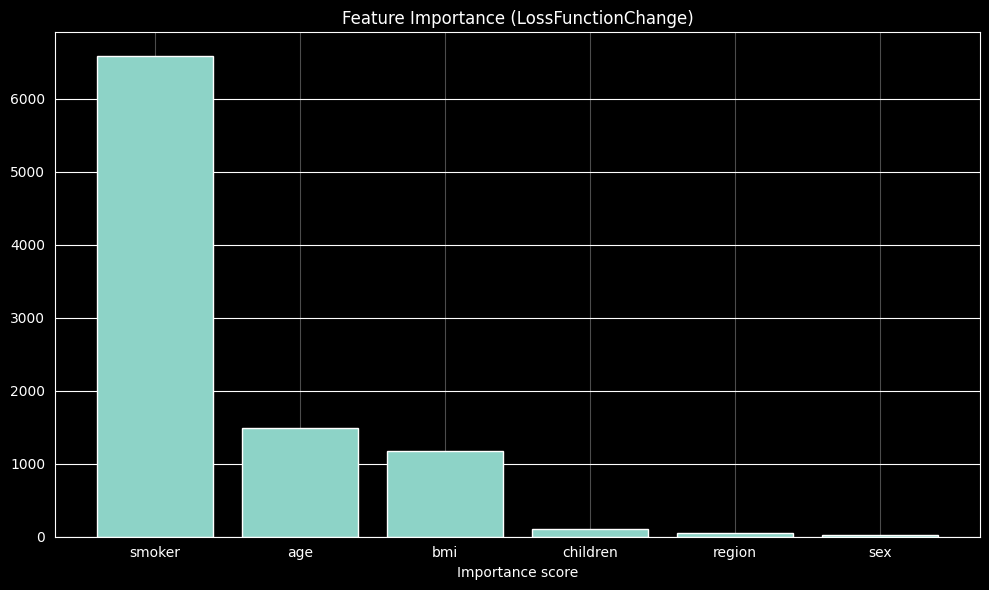

In [41]:
importance_lfc = model.get_feature_importance(train_pool, type="LossFunctionChange")

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Importance": importance_lfc
        }
    )
    .sort_values("Importance", ascending=False)
)


print(feature_importance_df)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

ax.set_title("Feature Importance (LossFunctionChange)")
ax.set_xlabel("Importance score")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

# snaphot support



In [44]:
importance_pvc = model.get_feature_importance(train_pool, type="PredictionValuesChange")

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Importance": importance_pvc
        }
    )
    .sort_values("Importance", ascending=False)
)

In [45]:
params = {
    'iterations': 5,
    'learning_rate': 0.5,
    'depth': 6,
    'loss_function': 'RMSE',
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'logging_level': 'Verbose'
}

In [46]:
model = CatBoostRegressor(**params).fit(train_pool, eval_set=val_pool, save_snapshot=True)

0:	learn: 7715.1550706	test: 8522.1324187	best: 8522.1324187 (0)	total: 8.34ms	remaining: 33.4ms
1:	learn: 5795.5383820	test: 6590.3182168	best: 6590.3182168 (1)	total: 11.4ms	remaining: 17.1ms
2:	learn: 5274.0651898	test: 6147.6864116	best: 6147.6864116 (2)	total: 12.2ms	remaining: 8.16ms
3:	learn: 4694.9351354	test: 5552.8755915	best: 5552.8755915 (3)	total: 13.7ms	remaining: 3.41ms
4:	learn: 4414.5201033	test: 5352.1075277	best: 5352.1075277 (4)	total: 15.4ms	remaining: 0us

bestTest = 5352.107528
bestIteration = 4



In [49]:
params.update({
    'iterations': 20,
    'learning_rate': 0.1,
})

model = CatBoostRegressor(**params).fit(train_pool, eval_set=val_pool, save_snapshot=True)


bestTest = 5288.956858
bestIteration = 17

Shrink model to first 18 iterations.
